In [4]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

BASE_DIR = "SEC_FINAL"

# Horizons à comparer
HORIZONS = ["1d", "1w", "2w", "1m", "2m", "3m"]

importances_results = {}   # {sector: {horizon: {feat: importance}}}
accuracy_results    = {}   # {sector: {horizon: accuracy}}

In [5]:
def load_sector_data(sector_path, horizon: str, min_company_ratio: float = 0.8):
    """
    Charge les CSV d'un secteur pour un horizon donné.
    Les colonnes cibles et prix des AUTRES horizons sont exclues des features.
    """
    target_col  = f"return_{horizon}"
    price_cols  = {"price_t"} | {f"price_t_plus_{m}" for m in HORIZONS}
    return_cols = {f"return_{m}" for m in HORIZONS}
    meta_cols   = {"filed", "year_current", "year_previous", "period"} | price_cols | return_cols

    dfs            = []
    feature_counts = {}
    company_count  = 0

    for file in os.listdir(sector_path):
        if not file.endswith(".csv"):
            continue

        df = pd.read_csv(os.path.join(sector_path, file))
        if df.shape[0] < 5:
            continue

        # Vérifie que la colonne cible existe pour cet horizon
        if target_col not in df.columns:
            continue

        features = set(df.columns) - meta_cols
        for feat in features:
            feature_counts[feat] = feature_counts.get(feat, 0) + 1

        dfs.append((df, features))
        company_count += 1

    if company_count == 0:
        return None

    # Features présentes dans au moins min_company_ratio des compagnies
    min_count         = int(np.ceil(min_company_ratio * company_count))
    selected_features = [f for f, c in feature_counts.items() if c >= min_count]

    if not selected_features:
        return None

    # Ne garder que les compagnies qui ont toutes ces features
    filtered = [df for df, feats in dfs if all(f in feats for f in selected_features)]
    if not filtered:
        return None

    df_all = pd.concat(filtered, ignore_index=True)
    return df_all, selected_features, target_col


# ══════════════════════════════════════════════════════════════════
# TRAIN MODEL POUR UN HORIZON
# ══════════════════════════════════════════════════════════════════

def train_one_horizon(sector_name: str, sector_path: str, horizon: str):
    """Entraîne un XGBoost pour un secteur et un horizon donné."""

    data = load_sector_data(sector_path, horizon)
    if data is None:
        print(f"      Pas de données pour horizon +{horizon}")
        return None, None

    df, features, target_col = data

    df = df.dropna(subset=[target_col] + features).copy()
    df["target"] = (df[target_col] > 0).astype(int)

    if df.shape[0] < 50:
        print(f"      Pas assez de lignes ({df.shape[0]}) pour +{horizon}")
        return None, None

    X = df[features]
    y = df["target"]

    # Équilibrage des classes
    counts           = y.value_counts()
    n_neg, n_pos     = counts.get(0, 1), counts.get(1, 1)
    scale_pos_weight = n_neg / n_pos

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        verbosity=0,
    )
    model.fit(X_train, y_train)

    y_pred   = model.predict(X_test)
    acc      = accuracy_score(y_test, y_pred)
    report   = classification_report(y_test, y_pred, output_dict=False)

    print(f"    {horizon:>3} | n={df.shape[0]:>4} | accuracy={acc:.4f} | "
          f"scale_pos_weight={scale_pos_weight:.2f}")
    print(report)

    # Importances
    feat_arr   = np.array(features)
    imp        = model.feature_importances_
    sorted_idx = np.argsort(imp)[::-1]

    return acc, dict(zip(feat_arr[sorted_idx], imp[sorted_idx]))


# ══════════════════════════════════════════════════════════════════
# TRAIN TOUS LES HORIZONS POUR UN SECTEUR
# ══════════════════════════════════════════════════════════════════

def train_sector(sector_name: str, sector_path: str):
    print(f"\n{'═'*60}")
    print(f"  SECTEUR : {sector_name}")
    print(f"{'═'*60}")

    sector_acc  = {}
    sector_imps = {}

    for horizon in HORIZONS:
        acc, importances = train_one_horizon(sector_name, sector_path, horizon)
        if acc is not None:
            sector_acc[horizon]  = acc
            sector_imps[horizon] = importances

    if not sector_acc:
        return

    accuracy_results[sector_name]    = sector_acc
    importances_results[sector_name] = sector_imps

    # ── Graphique comparatif des accuracies par horizon ──────────────
    fig, axes = plt.subplots(1, len(sector_acc), figsize=(6 * len(sector_acc), 5))
    if len(sector_acc) == 1:
        axes = [axes]

    for ax, horizon in zip(axes, sorted(sector_acc.keys())):
        imps      = sector_imps[horizon]
        top_feats = list(imps.keys())[:15]
        top_imps  = [imps[f] for f in top_feats]

        ax.barh(top_feats[::-1], top_imps[::-1])
        ax.set_title(f"+{horizon}  (acc={sector_acc[horizon]:.3f})")
        ax.set_xlabel("Importance")
        ax.tick_params(axis="y", labelsize=8)

    fig.suptitle(f"Top 15 features — {sector_name}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    


════════════════════════════════════════════════════════════
  SECTEUR : Basic Materials
════════════════════════════════════════════════════════════
     1d | n= 268 | accuracy=0.6481 | scale_pos_weight=0.89
              precision    recall  f1-score   support

           0       0.71      0.59      0.64        29
           1       0.60      0.72      0.65        25

    accuracy                           0.65        54
   macro avg       0.65      0.65      0.65        54
weighted avg       0.66      0.65      0.65        54

     1w | n= 268 | accuracy=0.5741 | scale_pos_weight=0.71
              precision    recall  f1-score   support

           0       0.54      0.52      0.53        25
           1       0.60      0.62      0.61        29

    accuracy                           0.57        54
   macro avg       0.57      0.57      0.57        54
weighted avg       0.57      0.57      0.57        54

     2w | n= 268 | accuracy=0.5185 | scale_pos_weight=0.79
              prec

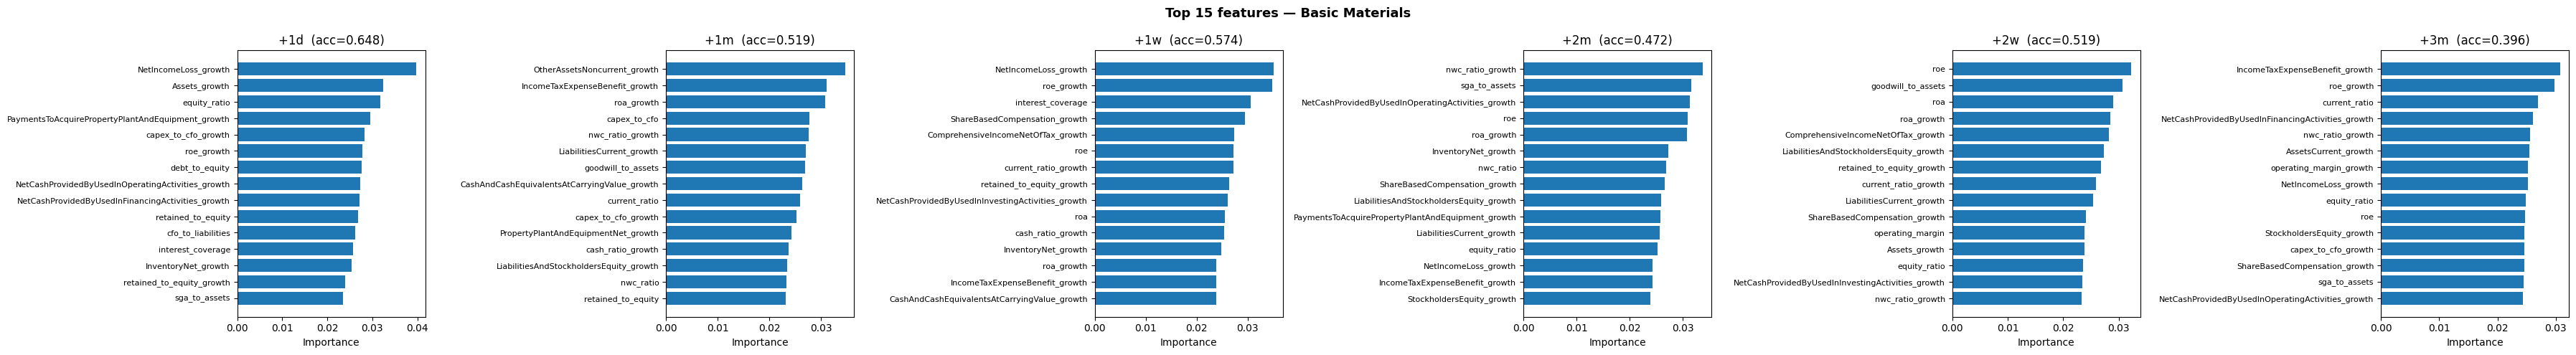


════════════════════════════════════════════════════════════
  SECTEUR : Communication Services
════════════════════════════════════════════════════════════
     1d | n=  71 | accuracy=0.6000 | scale_pos_weight=1.03
              precision    recall  f1-score   support

           0       0.64      0.78      0.70         9
           1       0.50      0.33      0.40         6

    accuracy                           0.60        15
   macro avg       0.57      0.56      0.55        15
weighted avg       0.58      0.60      0.58        15

     1w | n=  71 | accuracy=0.6000 | scale_pos_weight=0.73
              precision    recall  f1-score   support

           0       0.45      1.00      0.62         5
           1       1.00      0.40      0.57        10

    accuracy                           0.60        15
   macro avg       0.73      0.70      0.60        15
weighted avg       0.82      0.60      0.59        15

     2w | n=  71 | accuracy=0.4000 | scale_pos_weight=1.03
           

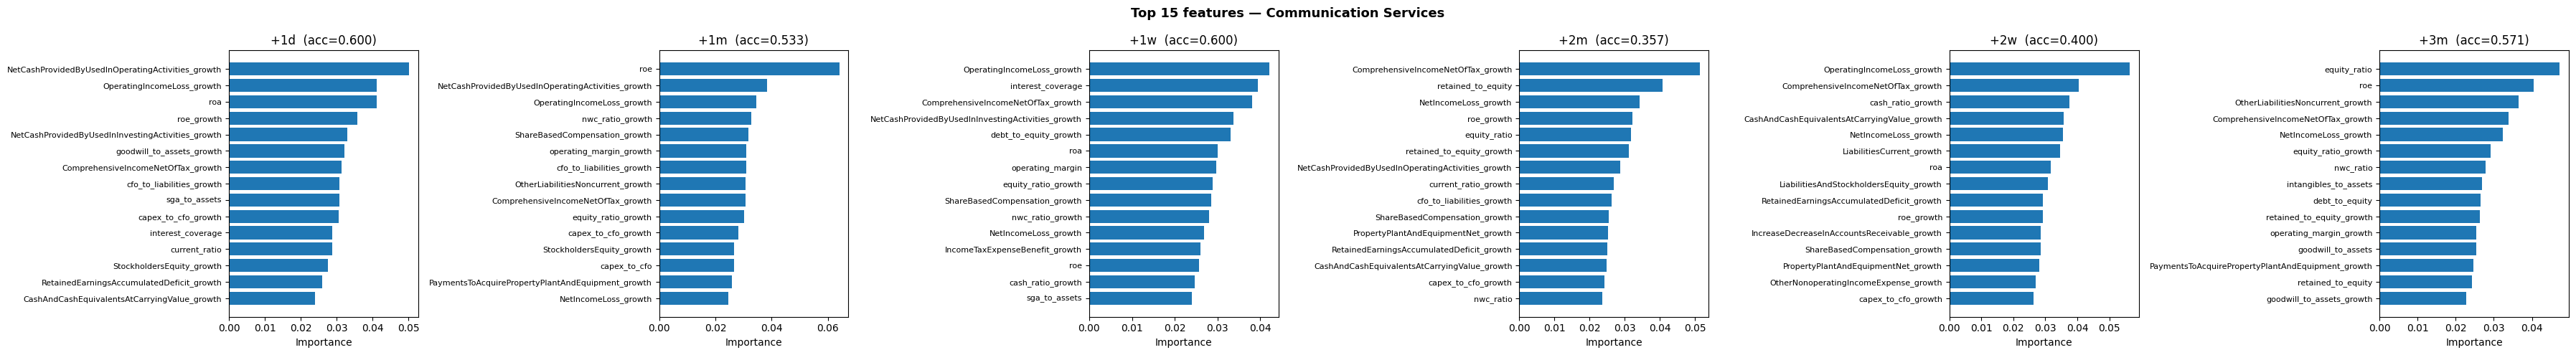


════════════════════════════════════════════════════════════
  SECTEUR : Consumer Cyclical
════════════════════════════════════════════════════════════
     1d | n= 270 | accuracy=0.5741 | scale_pos_weight=0.96
              precision    recall  f1-score   support

           0       0.56      0.21      0.30        24
           1       0.58      0.87      0.69        30

    accuracy                           0.57        54
   macro avg       0.57      0.54      0.50        54
weighted avg       0.57      0.57      0.52        54

     1w | n= 269 | accuracy=0.5000 | scale_pos_weight=1.02
              precision    recall  f1-score   support

           0       0.56      0.31      0.40        29
           1       0.47      0.72      0.57        25

    accuracy                           0.50        54
   macro avg       0.52      0.52      0.49        54
weighted avg       0.52      0.50      0.48        54

     2w | n= 269 | accuracy=0.5556 | scale_pos_weight=0.86
              pr

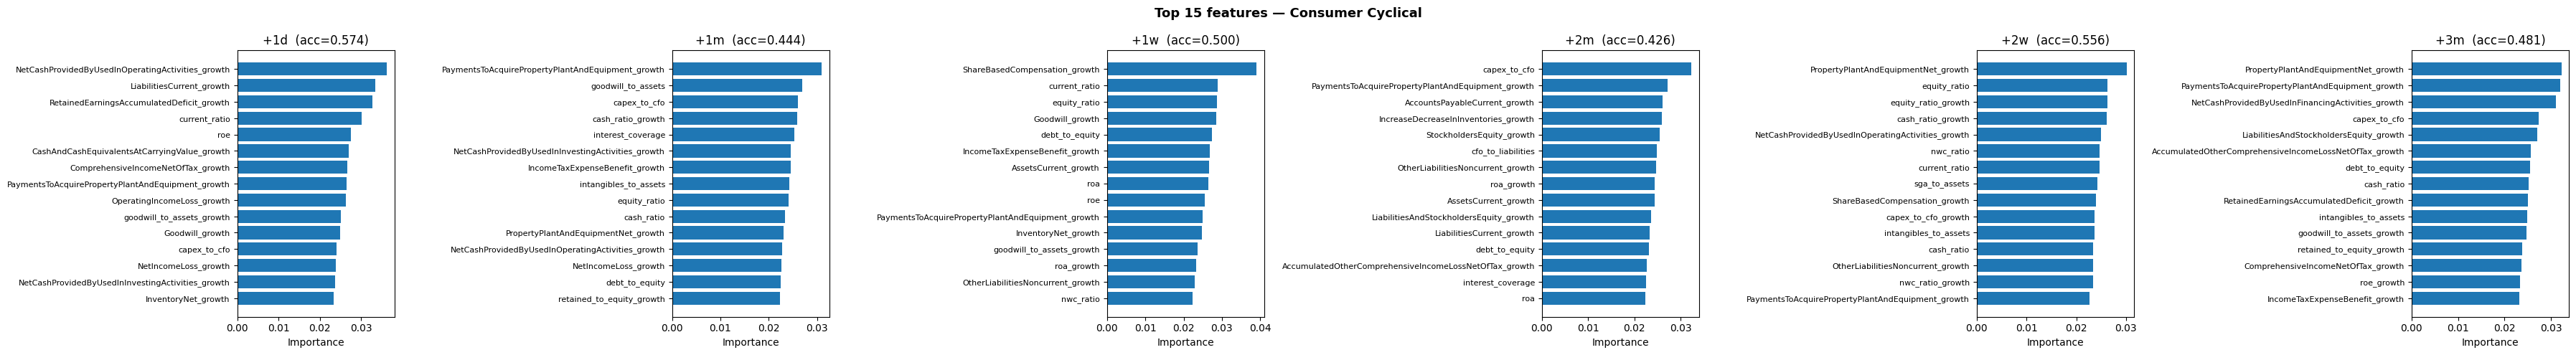


════════════════════════════════════════════════════════════
  SECTEUR : Consumer Defensive
════════════════════════════════════════════════════════════
      Pas assez de lignes (47) pour +1d
      Pas assez de lignes (47) pour +1w
      Pas assez de lignes (47) pour +2w
      Pas assez de lignes (47) pour +1m
      Pas assez de lignes (46) pour +2m
      Pas assez de lignes (46) pour +3m

════════════════════════════════════════════════════════════
  SECTEUR : Energy
════════════════════════════════════════════════════════════
      Pas assez de lignes (44) pour +1d
      Pas assez de lignes (44) pour +1w
      Pas assez de lignes (44) pour +2w
      Pas assez de lignes (43) pour +1m
      Pas assez de lignes (43) pour +2m
      Pas assez de lignes (43) pour +3m

════════════════════════════════════════════════════════════
  SECTEUR : Financial Services
════════════════════════════════════════════════════════════
     1d | n=  69 | accuracy=0.5000 | scale_pos_weight=0.68
           

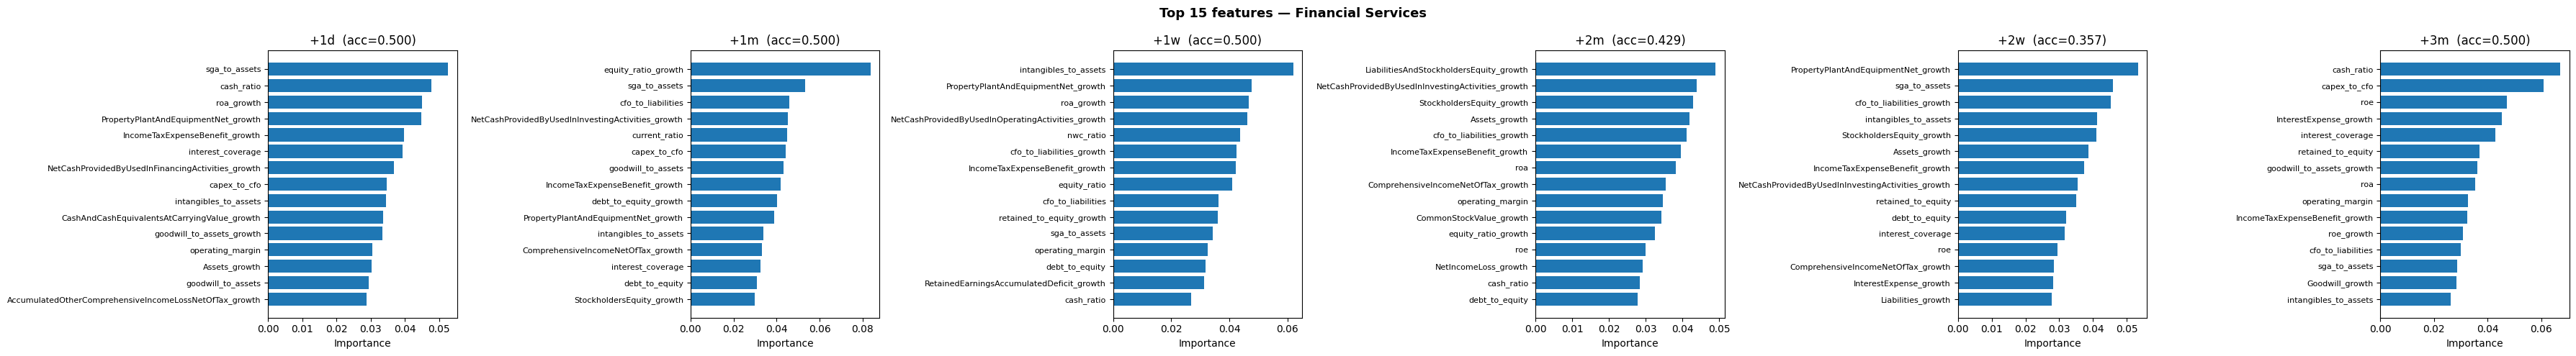


════════════════════════════════════════════════════════════
  SECTEUR : Healthcare
════════════════════════════════════════════════════════════
     1d | n= 391 | accuracy=0.4810 | scale_pos_weight=0.90
              precision    recall  f1-score   support

           0       0.51      0.45      0.48        42
           1       0.45      0.51      0.48        37

    accuracy                           0.48        79
   macro avg       0.48      0.48      0.48        79
weighted avg       0.48      0.48      0.48        79

     1w | n= 391 | accuracy=0.4177 | scale_pos_weight=1.01
              precision    recall  f1-score   support

           0       0.39      0.73      0.51        33
           1       0.50      0.20      0.28        46

    accuracy                           0.42        79
   macro avg       0.45      0.46      0.40        79
weighted avg       0.46      0.42      0.38        79

     2w | n= 391 | accuracy=0.5316 | scale_pos_weight=1.03
              precision

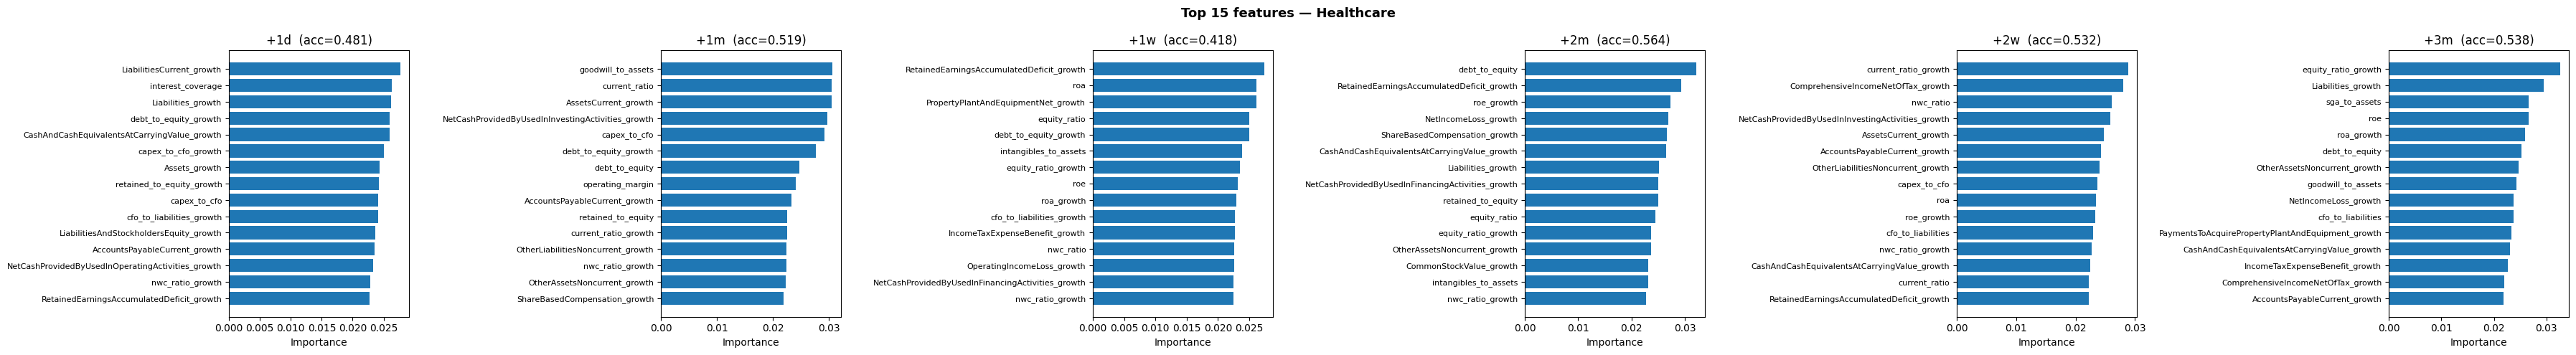


════════════════════════════════════════════════════════════
  SECTEUR : Industrials
════════════════════════════════════════════════════════════
     1d | n= 336 | accuracy=0.5294 | scale_pos_weight=1.02
              precision    recall  f1-score   support

           0       0.54      0.54      0.54        35
           1       0.52      0.52      0.52        33

    accuracy                           0.53        68
   macro avg       0.53      0.53      0.53        68
weighted avg       0.53      0.53      0.53        68

     1w | n= 336 | accuracy=0.5147 | scale_pos_weight=1.02
              precision    recall  f1-score   support

           0       0.47      0.55      0.51        31
           1       0.56      0.49      0.52        37

    accuracy                           0.51        68
   macro avg       0.52      0.52      0.51        68
weighted avg       0.52      0.51      0.52        68

     2w | n= 336 | accuracy=0.4412 | scale_pos_weight=0.89
              precisio

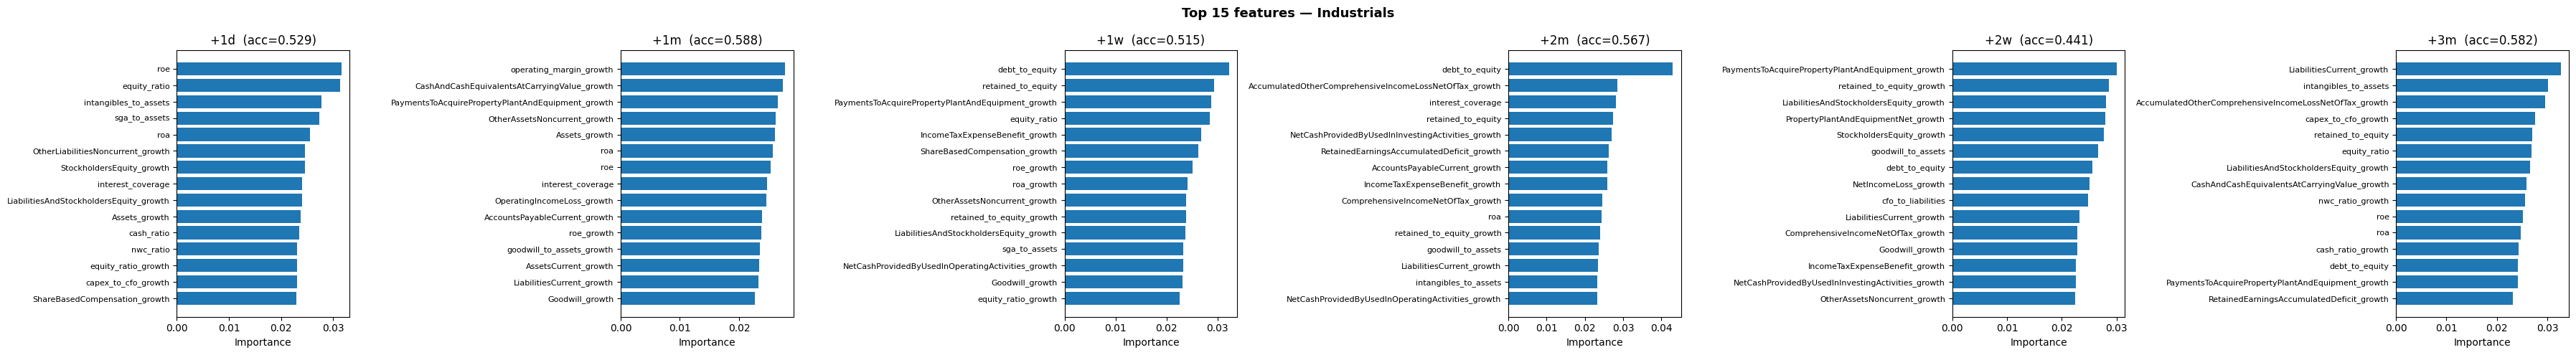


════════════════════════════════════════════════════════════
  SECTEUR : Real Estate
════════════════════════════════════════════════════════════
      Pas assez de lignes (5) pour +1d
      Pas assez de lignes (5) pour +1w
      Pas assez de lignes (5) pour +2w
      Pas assez de lignes (5) pour +1m
      Pas assez de lignes (5) pour +2m
      Pas assez de lignes (5) pour +3m

════════════════════════════════════════════════════════════
  SECTEUR : Technology
════════════════════════════════════════════════════════════
     1d | n= 280 | accuracy=0.5536 | scale_pos_weight=0.85
              precision    recall  f1-score   support

           0       0.48      0.54      0.51        24
           1       0.62      0.56      0.59        32

    accuracy                           0.55        56
   macro avg       0.55      0.55      0.55        56
weighted avg       0.56      0.55      0.56        56

     1w | n= 280 | accuracy=0.4643 | scale_pos_weight=1.00
              precision    r

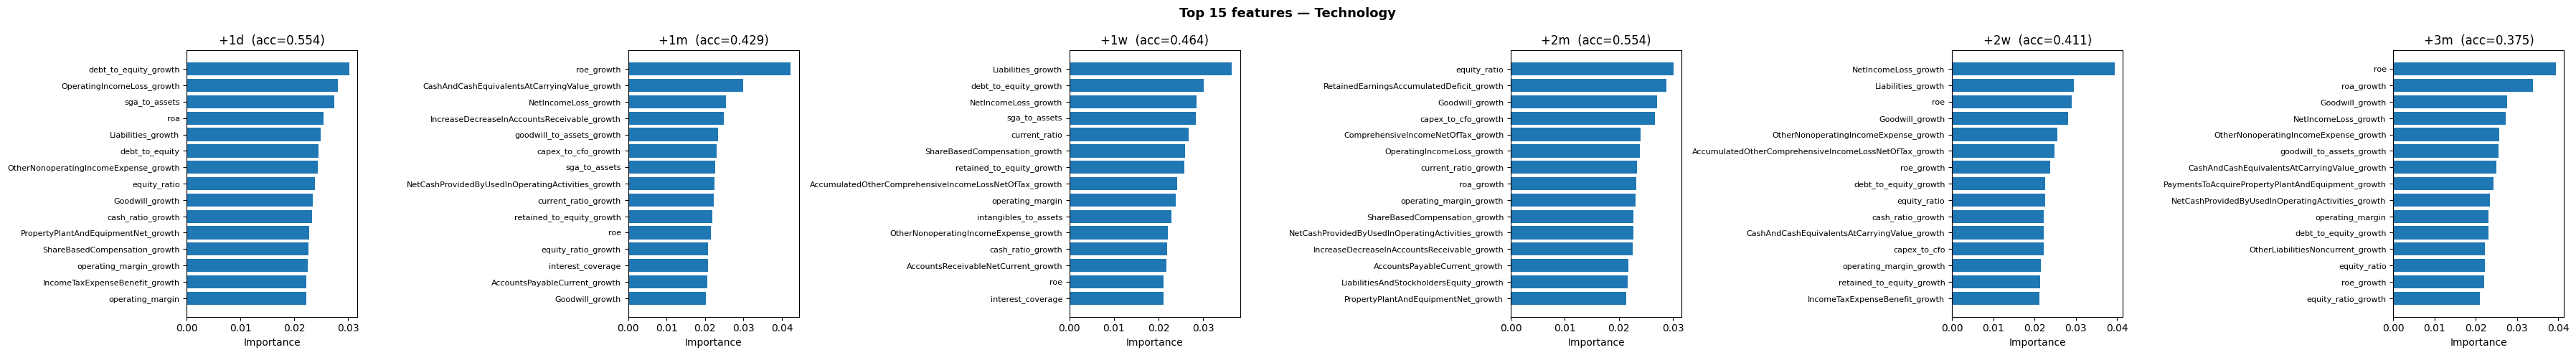


════════════════════════════════════════════════════════════
  SECTEUR : Utilities
════════════════════════════════════════════════════════════
      Pas assez de lignes (0) pour +1d
      Pas assez de lignes (0) pour +1w
      Pas assez de lignes (0) pour +2w
      Pas assez de lignes (0) pour +1m
      Pas assez de lignes (0) pour +2m
      Pas assez de lignes (0) pour +3m


════════════════════════════════════════════════════════════
  SYNTHÈSE — Accuracy par secteur et horizon
════════════════════════════════════════════════════════════
                           +1d     +1w     +2w     +1m     +2m     +3m best_horizon
Basic Materials         0.6481  0.5741  0.5185  0.5185  0.4717  0.3962          +1d
Communication Services  0.6000  0.6000  0.4000  0.5333  0.3571  0.5714          +1d
Consumer Cyclical       0.5741  0.5000  0.5556  0.4444  0.4259  0.4815          +1d
Financial Services      0.5000  0.5000  0.3571  0.5000  0.4286  0.5000          +1d
Healthcare              0.4810  

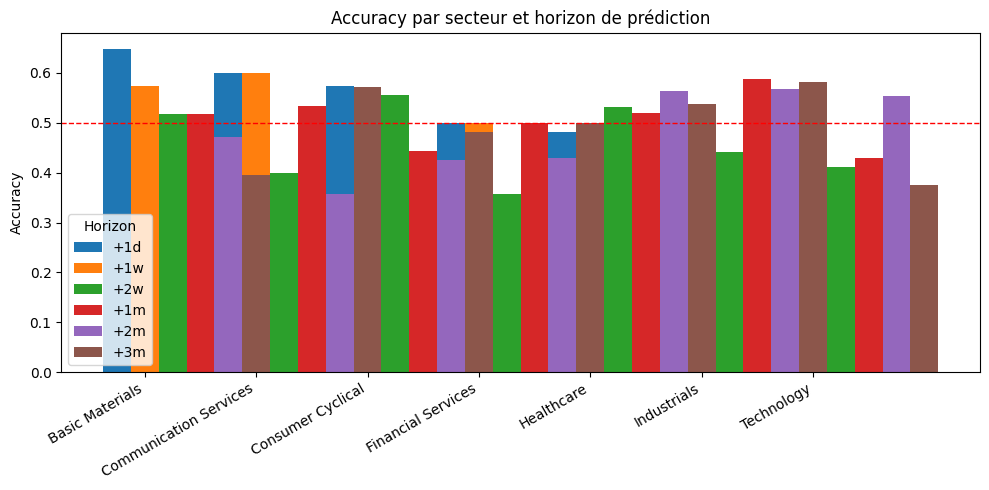



════════════════════════════════════════════════════════════
  TOP 10 FEATURES GLOBALES (moyenne toutes secteurs × horizons)
════════════════════════════════════════════════════════════
   1. InterestExpense_growth                                  0.0250
   2. cfo_to_liabilities_growth                               0.0238
   3. sga_to_assets                                           0.0236
   4. ComprehensiveIncomeNetOfTax_growth                      0.0235
   5. roe                                                     0.0235
   6. IncomeTaxExpenseBenefit_growth                          0.0230
   7. interest_coverage                                       0.0227
   8. PropertyPlantAndEquipmentNet_growth                     0.0227
   9. debt_to_equity_growth                                   0.0225
  10. NetIncomeLoss_growth                                    0.0225


In [6]:
for sector in sorted(os.listdir(BASE_DIR)):
    sector_path = os.path.join(BASE_DIR, sector)
    if os.path.isdir(sector_path):
        train_sector(sector, sector_path)


# ══════════════════════════════════════════════════════════════════
# SYNTHÈSE GLOBALE : accuracy par secteur × horizon
# ══════════════════════════════════════════════════════════════════

print("\n\n" + "═"*60)
print("  SYNTHÈSE — Accuracy par secteur et horizon")
print("═"*60)

df_summary = pd.DataFrame(accuracy_results).T   # secteurs en lignes, horizons en colonnes
df_summary.columns = [f"+{h}" for h in df_summary.columns]
df_summary["best_horizon"] = df_summary.idxmax(axis=1)
print(df_summary.round(4).to_string())

# Graphique synthèse
fig, ax = plt.subplots(figsize=(10, 5))
df_plot = df_summary.drop(columns="best_horizon").astype(float)
x       = np.arange(len(df_plot))
width   = 0.25

for i, col in enumerate(df_plot.columns):
    ax.bar(x + i * width, df_plot[col], width, label=col)

ax.set_xticks(x + width)
ax.set_xticklabels(df_plot.index, rotation=30, ha="right")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy par secteur et horizon de prédiction")
ax.legend(title="Horizon")
ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="Baseline 50%")
plt.tight_layout()
plt.show()

# Top features globales (moyenne des importances sur tous horizons et secteurs)
print("\n\n" + "═"*60)
print("  TOP 10 FEATURES GLOBALES (moyenne toutes secteurs × horizons)")
print("═"*60)

global_imp = {}
for sector, horizons in importances_results.items():
    for horizon, imps in horizons.items():
        for feat, val in imps.items():
            global_imp.setdefault(feat, []).append(val)

global_imp_mean = {f: np.mean(v) for f, v in global_imp.items()}
for i, (feat, val) in enumerate(
    sorted(global_imp_mean.items(), key=lambda x: x[1], reverse=True)[:10], 1
):
    print(f"  {i:>2}. {feat:<55} {val:.4f}")

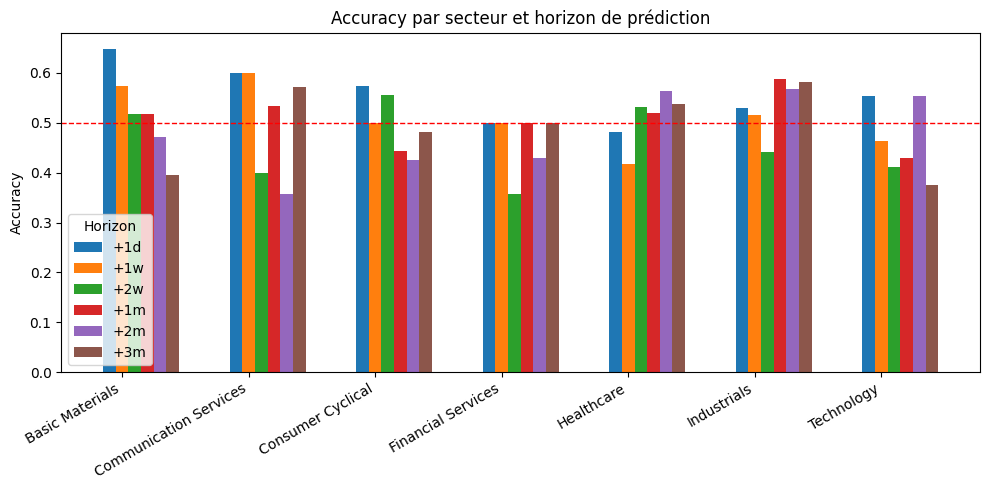

In [9]:
# Graphique synthèse
fig, ax = plt.subplots(figsize=(10, 5))
df_plot = df_summary.drop(columns="best_horizon").astype(float)
x       = np.arange(len(df_plot))
width   = 0.1

for i, col in enumerate(df_plot.columns):
    ax.bar(x + i * width, df_plot[col], width, label=col)

ax.set_xticks(x + width)
ax.set_xticklabels(df_plot.index, rotation=30, ha="right")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy par secteur et horizon de prédiction")
ax.legend(title="Horizon")
ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="Baseline 50%")
plt.tight_layout()
plt.show()


════════════════════════════════════════════════════════════
  TOUS LES SECTEURS COMBINÉS
════════════════════════════════════════════════════════════
   1d | n= 2839 | accuracy=0.5158 | scale_pos_weight=0.94
              precision    recall  f1-score   support

           0       0.53      0.47      0.50       289
           1       0.51      0.57      0.53       279

    accuracy                           0.52       568
   macro avg       0.52      0.52      0.52       568
weighted avg       0.52      0.52      0.51       568

   1w | n= 2837 | accuracy=0.5317 | scale_pos_weight=0.92
              precision    recall  f1-score   support

           0       0.52      0.48      0.50       277
           1       0.54      0.58      0.56       291

    accuracy                           0.53       568
   macro avg       0.53      0.53      0.53       568
weighted avg       0.53      0.53      0.53       568

   2w | n= 2836 | accuracy=0.5282 | scale_pos_weight=0.91
              precis

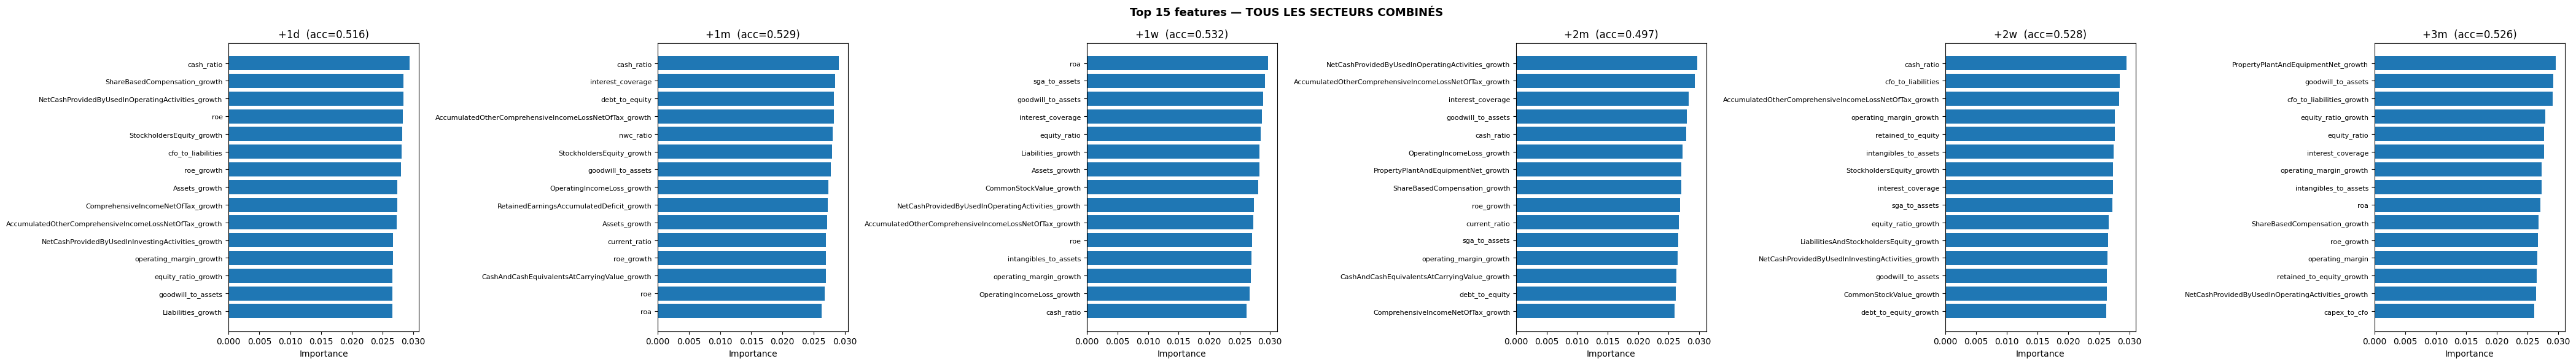


════════════════════════════════════════════════════════════
  SYNTHÈSE — Accuracy par horizon (tous secteurs combinés)
════════════════════════════════════════════════════════════
   1d: 0.5158
   1m: 0.5291
   1w: 0.5317
   2m: 0.4973
   2w: 0.5282
   3m: 0.5258


In [10]:
# ══════════════════════════════════════════════════════════════════
# TRAIN MODÈLES SUR TOUS LES SECTEURS COMBINÉS
# ══════════════════════════════════════════════════════════════════

def load_all_sectors_data(base_dir: str, horizon: str, min_company_ratio: float = 0.8):
    """
    Charge les CSV de TOUS les secteurs combinés pour un horizon donné.
    """
    target_col  = f"return_{horizon}"
    price_cols  = {"price_t"} | {f"price_t_plus_{m}" for m in HORIZONS}
    return_cols = {f"return_{m}" for m in HORIZONS}
    meta_cols   = {"filed", "year_current", "year_previous", "period"} | price_cols | return_cols

    dfs            = []
    feature_counts = {}
    company_count  = 0

    # Itère sur tous les secteurs
    for sector in os.listdir(base_dir):
        sector_path = os.path.join(base_dir, sector)
        if not os.path.isdir(sector_path):
            continue

        for file in os.listdir(sector_path):
            if not file.endswith(".csv"):
                continue

            df = pd.read_csv(os.path.join(sector_path, file))
            if df.shape[0] < 5:
                continue

            # Vérifie que la colonne cible existe pour cet horizon
            if target_col not in df.columns:
                continue

            features = set(df.columns) - meta_cols
            for feat in features:
                feature_counts[feat] = feature_counts.get(feat, 0) + 1

            dfs.append((df, features))
            company_count += 1

    if company_count == 0:
        return None

    # Features présentes dans au moins min_company_ratio des compagnies
    min_count         = int(np.ceil(min_company_ratio * company_count))
    selected_features = [f for f, c in feature_counts.items() if c >= min_count]

    if not selected_features:
        return None

    # Ne garder que les compagnies qui ont toutes ces features
    filtered = [df for df, feats in dfs if all(f in feats for f in selected_features)]
    if not filtered:
        return None

    df_all = pd.concat(filtered, ignore_index=True)
    return df_all, selected_features, target_col


def train_global_horizons(base_dir: str):
    """Entraîne XGBoost sur tous les secteurs combinés pour chaque horizon."""
    print(f"\n{'═'*60}")
    print(f"  TOUS LES SECTEURS COMBINÉS")
    print(f"{'═'*60}")

    global_acc  = {}
    global_imps = {}

    for horizon in HORIZONS:
        data = load_all_sectors_data(base_dir, horizon)
        if data is None:
            print(f"  Pas de données pour horizon +{horizon}")
            continue

        df, features, target_col = data

        df = df.dropna(subset=[target_col] + features).copy()
        df["target"] = (df[target_col] > 0).astype(int)

        if df.shape[0] < 50:
            print(f"  Pas assez de lignes ({df.shape[0]}) pour +{horizon}")
            continue

        X = df[features]
        y = df["target"]

        # Équilibrage des classes
        counts           = y.value_counts()
        n_neg, n_pos     = counts.get(0, 1), counts.get(1, 1)
        scale_pos_weight = n_neg / n_pos

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, shuffle=False
        )

        model = XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            verbosity=0,
        )
        model.fit(X_train, y_train)

        y_pred   = model.predict(X_test)
        acc      = accuracy_score(y_test, y_pred)
        report   = classification_report(y_test, y_pred, output_dict=False)

        print(f"  {horizon:>3} | n={df.shape[0]:>5} | accuracy={acc:.4f} | "
              f"scale_pos_weight={scale_pos_weight:.2f}")
        print(report)

        # Importances
        feat_arr   = np.array(features)
        imp        = model.feature_importances_
        sorted_idx = np.argsort(imp)[::-1]

        global_acc[horizon]   = acc
        global_imps[horizon]  = dict(zip(feat_arr[sorted_idx], imp[sorted_idx]))

    if not global_acc:
        print("  Aucun modèle entraîné.")
        return

    # ── Graphique comparatif des importances par horizon ──────────────
    fig, axes = plt.subplots(1, len(global_acc), figsize=(7 * len(global_acc), 6))
    if len(global_acc) == 1:
        axes = [axes]

    for ax, horizon in zip(axes, sorted(global_acc.keys())):
        imps      = global_imps[horizon]
        top_feats = list(imps.keys())[:15]
        top_imps  = [imps[f] for f in top_feats]

        ax.barh(top_feats[::-1], top_imps[::-1])
        ax.set_title(f"+{horizon}  (acc={global_acc[horizon]:.3f})")
        ax.set_xlabel("Importance")
        ax.tick_params(axis="y", labelsize=8)

    fig.suptitle("Top 15 features — TOUS LES SECTEURS COMBINÉS", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # ── Résumé des accuracies ──
    print("\n" + "═"*60)
    print("  SYNTHÈSE — Accuracy par horizon (tous secteurs combinés)")
    print("═"*60)
    for horizon in sorted(global_acc.keys()):
        print(f"  {horizon:>3}: {global_acc[horizon]:.4f}")

    return global_acc, global_imps


# Entraîner les modèles globaux
global_all_acc, global_all_imps = train_global_horizons(BASE_DIR)